
Mirrors `targeted_vaccination_by_tier.ipynb` (LowProFool) but replaces the attack with
**PermuteAttack**  

- **Attack source**: `PermuteAttack-main/src/ga_attack.py` 

In [1]:
import sys
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Silence PermuteAttack's per-attack tqdm bar (would produce thousands of stacked bars
# during the full-test-set sweep). Patch BEFORE importing src.ga_attack so its
# `from tqdm import tqdm` binds to the no-op.
import tqdm as _tqdm
_tqdm.tqdm = lambda iterable, *args, **kwargs: iterable

PERMUTE_PATH = Path('../../../PermuteAttack-main').resolve()
sys.path.insert(0, str(PERMUTE_PATH))
from src.ga_attack import GAdvExample  # noqa: E402

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DATA_DIR = Path('../../data/spambase_10_40_50')
SCORES_DIR = Path('../../outputs/noise_scoring/20260324_203954')
OUTPUT_DIR = Path('../../outputs/permuteattack_targeted_vaccination_10_40_50')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Single regime to start. To compare attack constraints, add another entry here
# (e.g. one with larger `num_generations` or `n_runs`). The downstream sweep iterates
# over PERMUTE_REGIMES.keys() the same way the LowProFool notebook iterates over
# LAMBDAS.keys().
PERMUTE_REGIMES = {
    'default': {
        'sol_per_pop': 30,
        'num_parents_mating': 10,
        'num_generations': 100,
        'n_runs': 10,
        'beta': 0.95,
    },
}

ATTACK_PCTS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
K_RANKS = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]

# Set to an int (e.g. 200) for a quick partial run; None = attack every correctly
# classified test point, matching the LowProFool notebook.
MAX_SAMPLES = None


Device: cuda
GPU: NVIDIA RTX A6000


## 1. Load Data, Model, and Noise Scores


In [2]:
data = np.load(DATA_DIR / 'train_test_data.npz')
X_train_partition = data['X_train'].astype(np.float32)  # PermuteAttack permutation pool
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test']
n_test, n_features = X_test.shape

prep = np.load(DATA_DIR / 'preprocessing.npz')
bounds = [prep['bounds_min'], prep['bounds_max']]


class SpambaseNet(nn.Module):
    def __init__(self, D_in):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)


checkpoint = torch.load(DATA_DIR / 'spambase_mlp.pth', map_location=device)
model = SpambaseNet(checkpoint['D_in']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

X_test_t = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    test_preds = model(X_test_t).argmax(dim=1).cpu().numpy()
correct_mask = (test_preds == y_test)
correct_indices = np.where(correct_mask)[0]
n_correct = len(correct_indices)

print(f'Train partition (PermuteAttack marginals): {X_train_partition.shape}')
print(f'Test set: {n_test} samples, {n_features} features')
print(f'Correctly classified: {n_correct}/{n_test} ({n_correct/n_test:.2%})')


Train partition (PermuteAttack marginals): (1840, 57)
Test set: 2301 samples, 57 features
Correctly classified: 2058/2301 (89.44%)


In [3]:
score1_removal_order = np.load(SCORES_DIR / 'test_clean_data_score1_removed_index.npy').astype(int)
score2_value = np.load(SCORES_DIR / 'test_clean_data_score2_noise_scores.npy')

# Noisiest-first orderings, filtered to correctly-classified only
score1_order = [idx for idx in score1_removal_order if correct_mask[idx]]
score2_order = [idx for idx in np.argsort(score2_value)[::-1] if correct_mask[idx]]

score_orders = {'Score 1': score1_order, 'Score 2': score2_order}
print(f'Eligible points per score ordering: {len(score1_order)}')


Eligible points per score ordering: 2057


## 2. Attack All Correctly-Classified Points (PermuteAttack)


In [4]:
class TorchModelWrapper:
    """Expose sklearn-style predict / predict_proba for a torch MLP whose forward()
    already returns softmax probabilities. PermuteAttack only requires forward passes."""

    def __init__(self, torch_model, device):
        self.model = torch_model
        self.device = device
        self.model.eval()

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        with torch.no_grad():
            probs = self.model(torch.FloatTensor(X).to(self.device)).cpu().numpy()
        return probs

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)


def permute_attack(x_orig, model_wrapper, x_train_pool, regime_cfg):
    """Run PermuteAttack on a single sample.

    Returns
    -------
    (x_adv_1d, success_flag)
        If a successful counterfactual is found, returns it (1d numpy array) and 1.
        Otherwise returns the unmodified sample and 0. This matches LowProFool's
        "if no attack succeeds, best_pert_x stays at x" semantics so the downstream
        vaccination sweep code is reused unchanged.
    """
    attacker = GAdvExample(
        cat_vars_ohe=None,        # Spambase is all continuous, no one-hot groups
        feature_names=None,
        sol_per_pop=regime_cfg['sol_per_pop'],
        num_parents_mating=regime_cfg['num_parents_mating'],
        num_generations=regime_cfg['num_generations'],
        n_runs=regime_cfg['n_runs'],
        black_list=None,          # no non-editable features for Spambase
        beta=regime_cfg['beta'],
        verbose=False,
        target=None,              # binary, target = 1 - orig
    )
    x_in = np.asarray(x_orig, dtype=np.float32).reshape(1, -1)
    _, _, x_sucess = attacker.attack(model_wrapper, x_in, x_train_pool)
    if len(x_sucess) > 0:
        return np.asarray(x_sucess[0], dtype=np.float32), 1
    return np.asarray(x_orig, dtype=np.float32).flatten(), 0


model_wrapper = TorchModelWrapper(model, device)


In [5]:
# Smoke test: run PermuteAttack on 5 samples and estimate full-run wall time
# *before* committing to the full sweep. Aborting from here costs ~30-90 seconds
# instead of multiple hours if something is misconfigured.
print('Smoke test: 5 samples')
smoke_indices = correct_indices[:5]
t0 = time.time()
smoke_results = []
for idx in smoke_indices:
    t_start = time.time()
    _, succ = permute_attack(
        X_test[idx], model_wrapper, X_train_partition, PERMUTE_REGIMES['default']
    )
    dt = time.time() - t_start
    smoke_results.append((idx, succ, dt))
    print(f'  sample {idx}: success={succ}, took {dt:.1f}s')

elapsed = time.time() - t0
per_sample = elapsed / len(smoke_results)
planned_n = len(correct_indices) if MAX_SAMPLES is None else min(MAX_SAMPLES, len(correct_indices))
projected = per_sample * planned_n * len(PERMUTE_REGIMES)
print(f'\nMean: {per_sample:.1f}s/sample')
print(f'Projected full run ({planned_n} samples x {len(PERMUTE_REGIMES)} regime(s)): '
      f'{projected/60:.1f} min ({projected/3600:.2f} hr)')
print(f'Smoke-test success rate: {sum(s for _, s, _ in smoke_results)}/{len(smoke_results)}')


Smoke test: 5 samples
  sample 1: success=1, took 0.3s
  sample 3: success=1, took 1.1s
  sample 4: success=1, took 0.5s
  sample 5: success=1, took 1.0s
  sample 6: success=1, took 0.4s

Mean: 0.7s/sample
Projected full run (2058 samples x 1 regime(s)): 22.7 min (0.38 hr)
Smoke-test success rate: 5/5


In [6]:
attack_indices = correct_indices if MAX_SAMPLES is None else correct_indices[:MAX_SAMPLES]
n_attack = len(attack_indices)

X_adv = {}
attack_success = {}

for regime_name, regime_cfg in PERMUTE_REGIMES.items():
    print(f'\n{"=" * 60}')
    print(f'  {regime_name.upper()}  '
          f'(pop={regime_cfg["sol_per_pop"]}, '
          f'gens={regime_cfg["num_generations"]}, '
          f'runs={regime_cfg["n_runs"]})')
    print(f'{"=" * 60}')

    adv_matrix = np.copy(X_test)
    success = np.zeros(n_test, dtype=int)
    t0 = time.time()

    for i, idx in enumerate(attack_indices):
        x_adv, succ = permute_attack(
            X_test[idx], model_wrapper, X_train_partition, regime_cfg
        )
        adv_matrix[idx] = x_adv
        success[idx] = succ

        if (i + 1) % 50 == 0 or i == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i + 1) * (n_attack - i - 1)
            n_succ_so_far = int(success[attack_indices[:i + 1]].sum())
            print(f'  [{i + 1:>4d}/{n_attack}] '
                  f'success so far: {n_succ_so_far}/{i + 1} ({n_succ_so_far / (i + 1):.1%}) | '
                  f'elapsed: {elapsed:.0f}s | ETA: {eta/60:.1f} min')

    n_succ = int(success[attack_indices].sum())
    print(f'  Done: {n_succ}/{n_attack} ({n_succ / n_attack:.2%}) | '
          f'total {time.time() - t0:.0f}s')

    X_adv[regime_name] = adv_matrix
    attack_success[regime_name] = success

savez_kwargs = {}
for regime_name in PERMUTE_REGIMES:
    savez_kwargs[f'X_adv_{regime_name}'] = X_adv[regime_name]
    savez_kwargs[f'success_{regime_name}'] = attack_success[regime_name]
np.savez_compressed(OUTPUT_DIR / 'adversarial_samples.npz', **savez_kwargs)
print('\nAdversarial samples saved to', OUTPUT_DIR / 'adversarial_samples.npz')



  DEFAULT  (pop=30, gens=100, runs=10)
  [   1/2058] success so far: 1/1 (100.0%) | elapsed: 0s | ETA: 12.8 min
  [  50/2058] success so far: 50/50 (100.0%) | elapsed: 30s | ETA: 20.1 min
  [ 100/2058] success so far: 98/100 (98.0%) | elapsed: 58s | ETA: 18.9 min
  [ 150/2058] success so far: 147/150 (98.0%) | elapsed: 90s | ETA: 19.0 min
  [ 200/2058] success so far: 196/200 (98.0%) | elapsed: 119s | ETA: 18.4 min
  [ 250/2058] success so far: 244/250 (97.6%) | elapsed: 152s | ETA: 18.3 min
  [ 300/2058] success so far: 293/300 (97.7%) | elapsed: 185s | ETA: 18.1 min
  [ 350/2058] success so far: 343/350 (98.0%) | elapsed: 217s | ETA: 17.6 min
  [ 400/2058] success so far: 392/400 (98.0%) | elapsed: 248s | ETA: 17.1 min
  [ 450/2058] success so far: 441/450 (98.0%) | elapsed: 277s | ETA: 16.5 min
  [ 500/2058] success so far: 491/500 (98.2%) | elapsed: 305s | ETA: 15.8 min
  [ 550/2058] success so far: 541/550 (98.4%) | elapsed: 332s | ETA: 15.2 min
  [ 600/2058] success so far: 591/

## 3. Vaccination Sweep

Identical structure to the LowProFool variant — only the source of `X_adv` differs.


In [7]:
rows = []
t_total = time.time()

for score_name, order in score_orders.items():
    n_eligible = len(order)
    for attack_pct in ATTACK_PCTS:
        n_attack_pct = max(1, int(n_eligible * attack_pct / 100))

        # Noisy tier: first n_attack_pct in noisiest-first order
        noisy_indices = order[:n_attack_pct]
        # Structural tier: last n_attack_pct in noisiest-first order (most structural)
        structural_indices = order[-n_attack_pct:]

        for tier_name, tier_idx in [('structural', structural_indices), ('noisy', noisy_indices)]:
            for regime in PERMUTE_REGIMES:
                X_mixed = np.copy(X_test)
                n_successfully_attacked = 0
                for idx in tier_idx:
                    if attack_success[regime][idx]:
                        X_mixed[idx] = X_adv[regime][idx]
                        n_successfully_attacked += 1

                if n_successfully_attacked == 0:
                    for k in K_RANKS:
                        rows.append({
                            'score_type': score_name, 'tier': tier_name, 'regime': regime,
                            'attack_pct': attack_pct, 'k': k,
                            'n_targeted': len(tier_idx), 'n_attacked': 0,
                            'restoration_rate': 0.0, 'asr_after': 0.0,
                        })
                    continue

                # Single SVD per mixed matrix, then evaluate at each k
                U, S, Vt = np.linalg.svd(X_mixed, full_matrices=False)

                for k in K_RANKS:
                    X_vacc = (U[:, :k] * S[:k]) @ Vt[:k, :]
                    X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)
                    with torch.no_grad():
                        preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()

                    n_restored = sum(
                        1 for idx in tier_idx
                        if attack_success[regime][idx] and preds[idx] == y_test[idx]
                    )
                    restoration_rate = n_restored / n_successfully_attacked

                    rows.append({
                        'score_type': score_name, 'tier': tier_name, 'regime': regime,
                        'attack_pct': attack_pct, 'k': k,
                        'n_targeted': len(tier_idx), 'n_attacked': n_successfully_attacked,
                        'restoration_rate': restoration_rate, 'asr_after': 1 - restoration_rate,
                    })

        print(f'{score_name} | attack_pct={attack_pct:>3d}% done ({time.time() - t_total:.1f}s)')

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / 'vaccination_sweep.csv', index=False)
print(f'\nSweep complete: {len(df)} rows, saved to {OUTPUT_DIR / "vaccination_sweep.csv"}')


Score 1 | attack_pct= 10% done (0.1s)
Score 1 | attack_pct= 20% done (0.1s)
Score 1 | attack_pct= 30% done (0.1s)
Score 1 | attack_pct= 40% done (0.1s)
Score 1 | attack_pct= 50% done (0.2s)
Score 1 | attack_pct= 60% done (0.2s)
Score 1 | attack_pct= 70% done (0.2s)
Score 1 | attack_pct= 80% done (0.3s)
Score 1 | attack_pct= 90% done (0.3s)
Score 1 | attack_pct=100% done (0.3s)
Score 2 | attack_pct= 10% done (0.4s)
Score 2 | attack_pct= 20% done (0.4s)
Score 2 | attack_pct= 30% done (0.4s)
Score 2 | attack_pct= 40% done (0.5s)
Score 2 | attack_pct= 50% done (0.5s)
Score 2 | attack_pct= 60% done (0.5s)
Score 2 | attack_pct= 70% done (0.5s)
Score 2 | attack_pct= 80% done (0.6s)
Score 2 | attack_pct= 90% done (0.6s)
Score 2 | attack_pct=100% done (0.6s)

Sweep complete: 440 rows, saved to ../../outputs/permuteattack_targeted_vaccination_10_40_50/vaccination_sweep.csv


## 4. Heatmaps


Saved vaccination_score1_structural.png


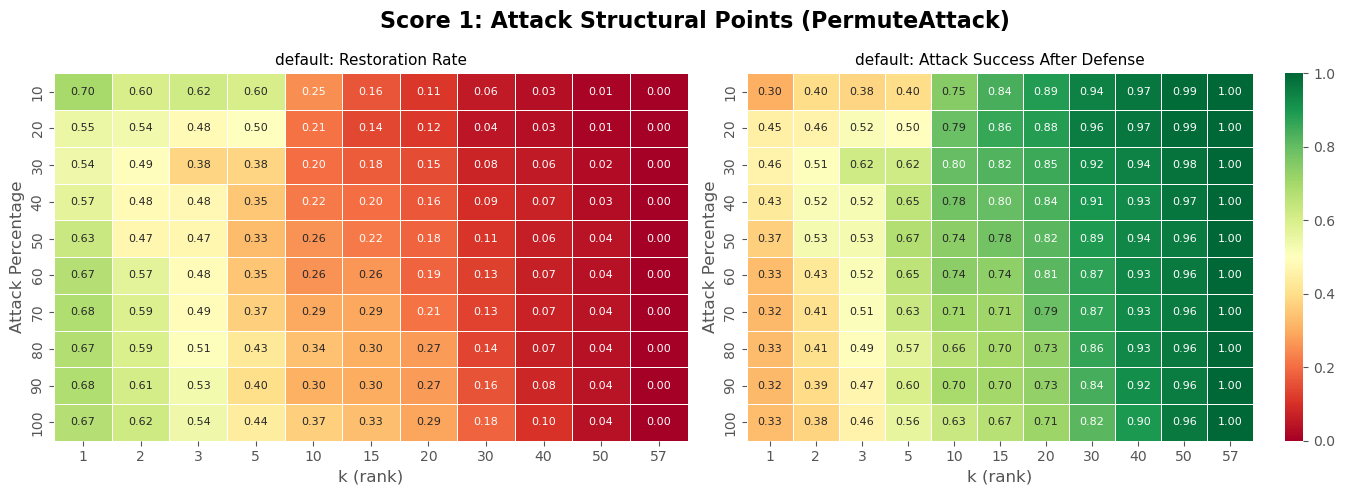

Saved vaccination_score1_noisy.png


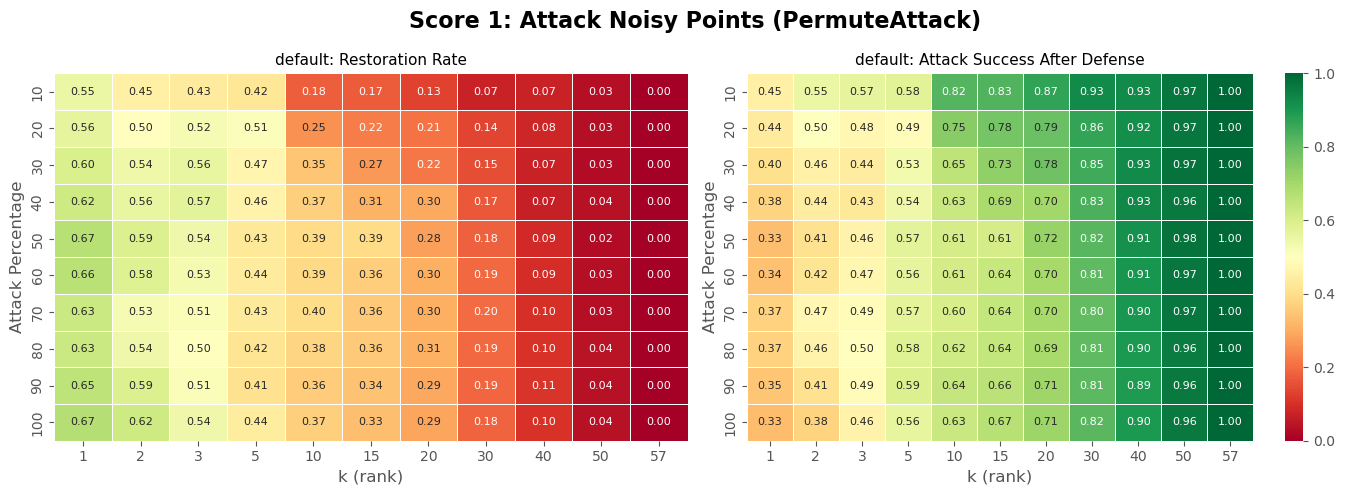

Saved vaccination_score2_structural.png


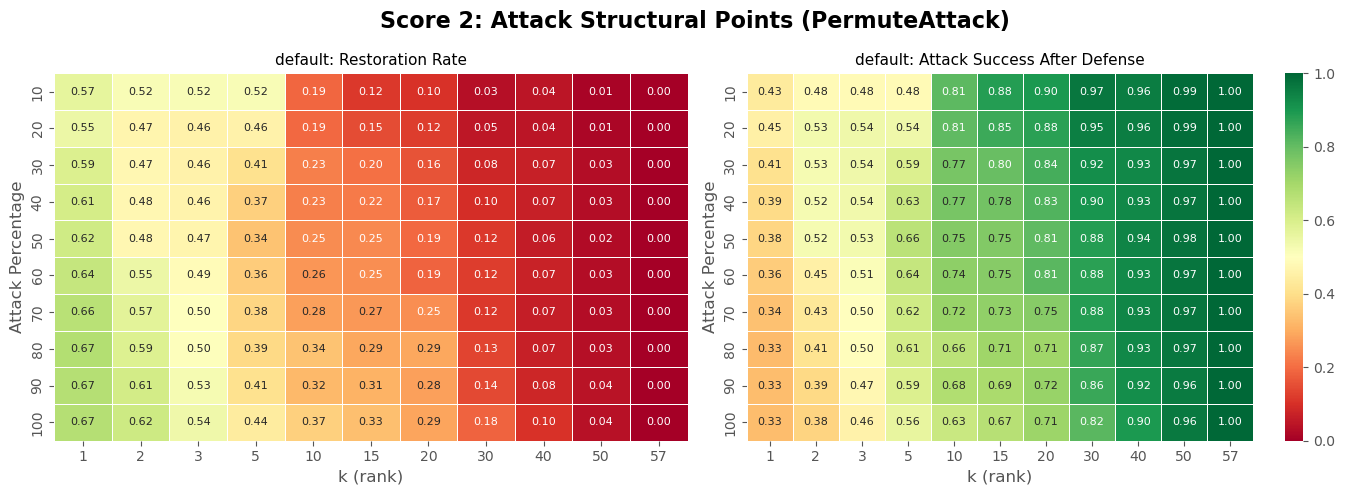

Saved vaccination_score2_noisy.png


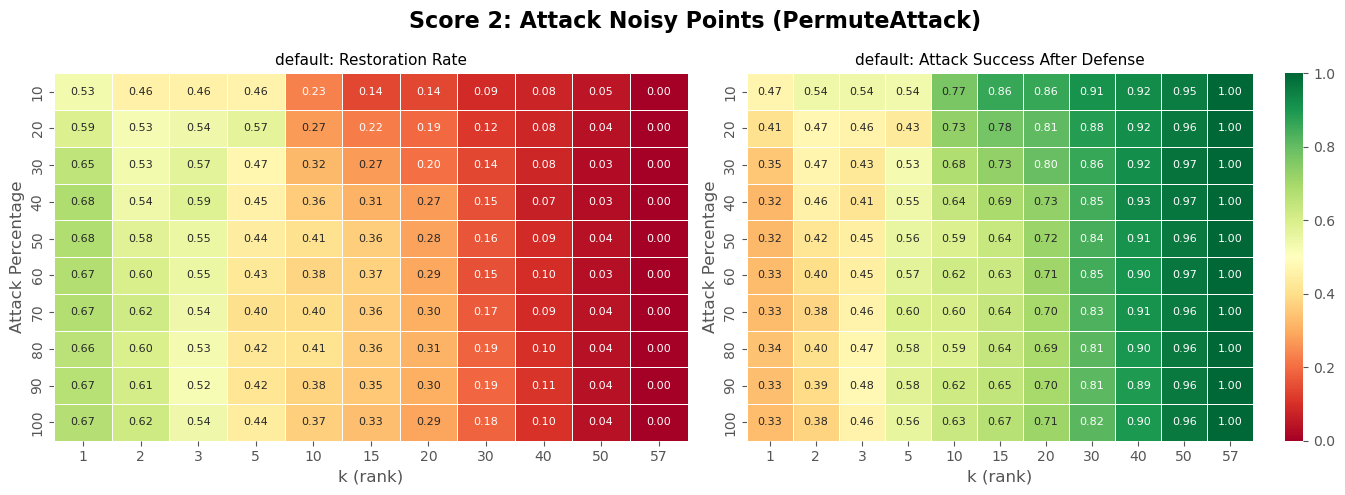

In [8]:
def plot_vaccination_heatmaps(df, score_name, tier_name, output_dir, regimes):
    """Heatmap per regime: restoration rate and post-defense ASR."""
    n_regimes = len(regimes)
    fig, axes = plt.subplots(n_regimes, 2, figsize=(14, 5 * n_regimes), squeeze=False)
    fig.suptitle(f'{score_name}: Attack {tier_name.capitalize()} Points (PermuteAttack)',
                 fontsize=16, fontweight='bold')

    sub = df[(df['score_type'] == score_name) & (df['tier'] == tier_name)]
    for row, regime in enumerate(regimes):
        for col, (metric, label) in enumerate([
            ('restoration_rate', 'Restoration Rate'),
            ('asr_after', 'Attack Success After Defense'),
        ]):
            ax = axes[row, col]
            regime_data = sub[sub['regime'] == regime]
            pivot = regime_data.pivot(index='attack_pct', columns='k', values=metric)
            pivot = pivot.sort_index(ascending=True)
            sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                        vmin=0, vmax=1, linewidths=0.5,
                        cbar=(col == 1), annot_kws={'size': 8})
            ax.set_title(f'{regime}: {label}', fontsize=11)
            ax.set_xlabel('k (rank)')
            ax.set_ylabel('Attack Percentage')

    plt.tight_layout()
    fname = f'vaccination_{score_name.lower().replace(" ", "")}_{tier_name}.png'
    fig.savefig(output_dir / fname, dpi=150, bbox_inches='tight')
    print(f'Saved {fname}')
    plt.show()


for score_name in score_orders:
    for tier_name in ['structural', 'noisy']:
        plot_vaccination_heatmaps(df, score_name, tier_name, OUTPUT_DIR,
                                  list(PERMUTE_REGIMES.keys()))


## 5. Save Summary


In [9]:
summary = {
    'attack': 'PermuteAttack (naive variant, Hashemi & Fathi 2020, arXiv:2008.10138)',
    'source_code': str(PERMUTE_PATH),
    'config': {
        'permute_regimes': PERMUTE_REGIMES,
        'attack_pcts': ATTACK_PCTS,
        'k_ranks': K_RANKS,
        'n_test': int(n_test),
        'n_correct': int(n_correct),
        'n_attacked_samples': int(n_attack),
        'max_samples_cap': MAX_SAMPLES,
        'data_dir': str(DATA_DIR),
        'data_split': '10/40/50 (SVD/train/test); test set unchanged vs legacy 50/50',
        'permute_train_marginal_source': '40% training partition (X_train, n=1840)',
    },
    'attack_success': {
        regime: int(attack_success[regime][attack_indices].sum())
        for regime in PERMUTE_REGIMES
    },
}
with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All results saved to', OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name:45s} ({p.stat().st_size / 1024:.1f} KB)')


All results saved to ../../outputs/permuteattack_targeted_vaccination_10_40_50
  adversarial_samples.npz                       (125.1 KB)
  summary.json                                  (1.0 KB)
  vaccination_score1_noisy.png                  (233.4 KB)
  vaccination_score1_structural.png             (235.4 KB)
  vaccination_score2_noisy.png                  (237.0 KB)
  vaccination_score2_structural.png             (230.3 KB)
  vaccination_sweep.csv                         (32.4 KB)
